# JT-SURF 2026 

The code below is the compilation of work completed during the Summer 2026 JT-SURF program at the Scripps Institute of Oceanography. Using a pseudo-atmosphere with controlled errors, it is the hope to see how machine learning and AI can be used to accurately forecast weather ptomatoictions.

In [36]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import plotly.express as px
import pandas as pd

#Lorenz's parameters
sigma = 10
beta = 8/3
rho = 28

In [37]:
# dy is a vector of the derivatives of the state variables, which are calculated based on the current state and the Lorenz equations.
# The function returns the derivatives as a numpy array.
def lorenz(t, y):

    dy = [sigma * (y[1] - y[0]), 
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return np.array(dy)

In [38]:
# RK4 Integrator
# fun is the ODE, dt is the timestep, t0 is the current time, and y0 is the current state
# function (x, t) -> function (t,y)
def rk4_step(fun, dt, t0, y0):
    f1 = fun(t0, y0)    #t0 equivalent to Xk
    f2 = fun(t0 + dt/2, y0 + dt/2 * f1)
    f3 = fun(t0 + dt/2, y0 + dt/2 * f2)
    f4 = fun(t0 + dt, y0 + dt * f3)
    yout = y0 + (dt/6) * (f1 + 2*f2 + 2*f3 + f4)
    return yout

In [39]:
#Forward Euler integration
def euler_step(y0, T, dt):
    # Compute the total number of time steps
    steps = int(T / dt) #Time steps = Total time / time step
    X = np.zeros((3, steps + 1)) 
    X[:, 0] = y0 #initialize the first column X with the initial condition y0 with 0 steps + 1 columns for the time steps
    x = y0.copy() #separate block of memory for the current state x to avoid modifying the original initial condition y0

    # Forward Euler integration
    for k in range(1, steps + 1):
        x = x + dt * lorenz(0, x)  # Update the state using the Lorenz equations
        X[:, k] = x  # Store the updated state in the trajectory array

    t = np.arange(0, T + dt, dt)
    return X, t  # Return the trajectory and corresponding time points

## Solve using various methods

In [40]:
# Initial conditions
y0 = np.array([1, 1, 1])      # Starting point in the Lorenz system

# Compute trajectrory using RK4
dt = 0.1                     #time steps 
T = 100                         #total time 

num_time_pts = int(T / dt) + 1 # number of time points and shows hoa many time values there are from the start to the end of the simulation. 
t_eval = np.linspace(0, T, num_time_pts) # use linspace to create a time vector 

#Solve using rk4
Y = np.zeros((3, num_time_pts)) # Y array holds the state variables of Xk through each step of the RK4 integration. 
Y[:, 0] = y0                    # Starting with y0 as the initial condition for the first column of Y. Continues to fill the Y array with the state variables at each time step.
yin = y0
for i in range (num_time_pts - 1):
    yout = rk4_step(lorenz, dt, t_eval[i], yin)
    Y[:, i + 1] = yout
    yin = yout
print("R4K first 10:" + str(Y[:, :10]))

# Solve using solve_ivp
lorenz_solution = solve_ivp(
    lorenz,
    [0, T],
    y0,
    t_eval=t_eval,
    method='RK45'
)
print("solve_ivp first 10:" + str(lorenz_solution.y[:, :10]))

t_ivp = lorenz_solution.t
y_ivp = lorenz_solution.y

#Solve using Euler 
Y_euler, t_euler = euler_step(y0, T, dt)
print("Euler first 10:" + str(Y_euler[:, :10])) 


R4K first 10:[[  1.           2.23690694   6.54205728  16.67964382  12.72318152
    0.9517379   -4.0292296   -6.15254078  -8.27956828 -10.22673302]
 [  1.           4.29534952  13.5076992   26.63256881   0.04819124
   -7.39987837  -6.99918535  -8.21548326 -10.59227949 -11.51954428]
 [  1.           1.09179853   4.14416637  26.27246175  45.60851592
   32.19397151  26.02637908  23.41988725  24.00673093  27.74610141]]
solve_ivp first 10:[[  1.           2.13316204   6.5343074   16.70002273  15.45546456
    1.23198295  -4.84353964  -7.04698983  -8.60266285  -9.65321311]
 [  1.           4.47121159  13.70066192  27.23479117   1.27524859
   -8.91266199  -8.0800391   -8.71663643 -10.03544329 -10.13211724]
 [  1.           1.11427948   4.19251173  26.1830105   46.93182167
   32.55754611  26.7579468   24.95778647  25.64737184  27.95863229]]
Euler first 10:[[ 1.00000000e+00  1.00000000e+00  3.60000000e+00  5.95666667e+00
   1.50914000e+01  2.85593762e+01  5.12316797e+01 -2.02307607e+01
  -8.1681

/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/2850322567.py:6: RuntimeWarning: overflow encountered in scalar multiply
  y[0] * (rho - y[2]) - y[1],
/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/2850322567.py:7: RuntimeWarning: overflow encountered in scalar multiply
  y[0] * y[1] - beta * y[2]]
/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/2850322567.py:6: RuntimeWarning: invalid value encountered in scalar subtract
  y[0] * (rho - y[2]) - y[1],
/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/797582246.py:11: RuntimeWarning: invalid value encountered in add
  x = x + dt * lorenz(0, x)  # Update the state using the Lorenz equations


## Plot Trajectory in time and 3D space

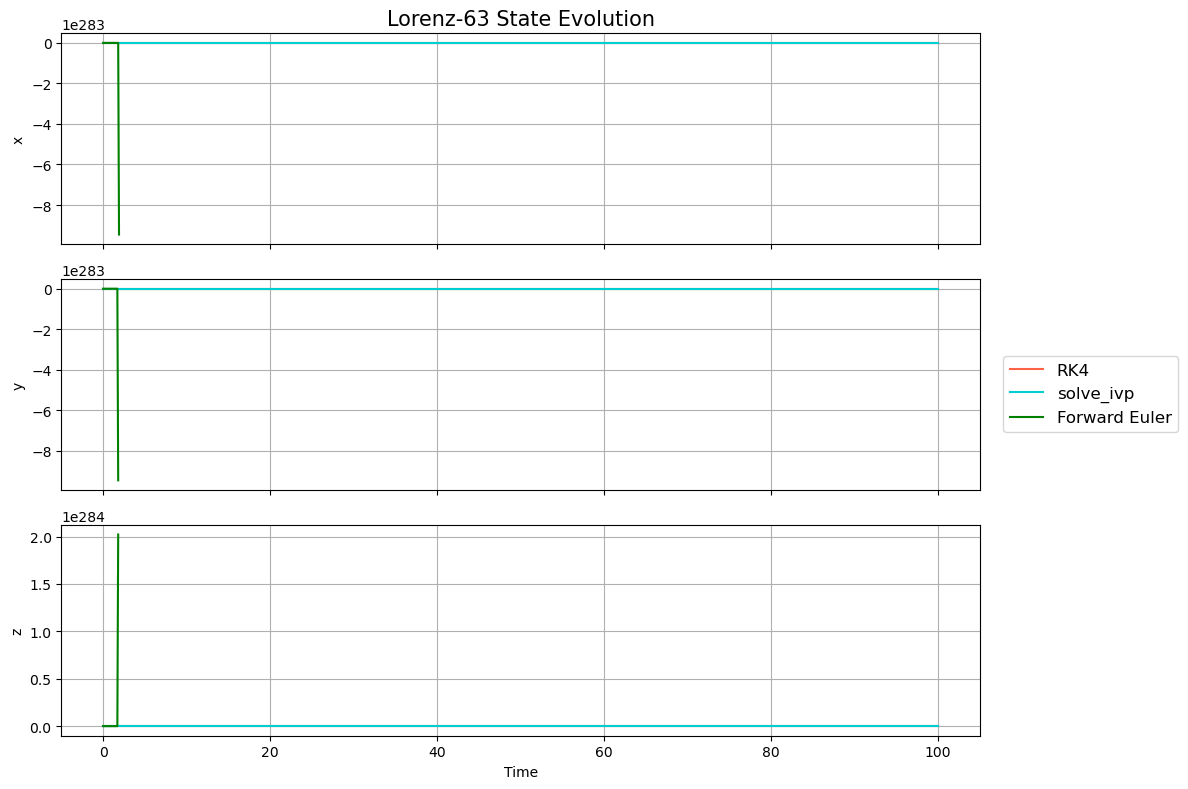

In [41]:
#Plot state evolution as a function of time 
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
# x(t)
ax[0].plot(t_eval, Y[0, :], color='tomato', label='RK4')
ax[0].plot(t_ivp, y_ivp[0, :], color='darkturquoise', label='solve_ivp')
ax[0].plot(t_euler, Y_euler[0, :], color='green', label='Forward Euler')
ax[0].set_ylabel('x')
ax[0].set_title('Lorenz-63 State Evolution', fontsize=15)
ax[0].grid(True)

# y(t)
ax[1].plot(t_eval, Y[1, :], color='tomato', label='RK4')
ax[1].plot(t_ivp, y_ivp[1, :], color='darkturquoise', label='solve_ivp')
ax[1].plot(t_euler, Y_euler[1, :], color='green', label='Forward Euler')
ax[1].set_ylabel('y')
ax[1].grid(True)

# z(t)
ax[2].plot(t_eval, Y[2, :], color='tomato', label='RK4')
ax[2].plot(t_ivp, y_ivp[2, :], color='darkturquoise', label='solve_ivp')
ax[2].plot(t_euler, Y_euler[2, :], color='green', label='Forward Euler')
ax[2].set_ylabel('z')
ax[2].set_xlabel('Time')
ax[2].grid(True)

# One legend outside the figure
fig.legend(
    ['RK4', 'solve_ivp', 'Forward Euler'],
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize = 12
)

plt.tight_layout()
plt.show()

/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/4157505680.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(Y[0, :], Y[1, :], Y[2, :],'b', color='tomato', lw=0.5, label = 'RK4')
/var/folders/2n/wlh3tggn2bn1vh_1b4_y55mm0000gn/T/ipykernel_376/4157505680.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.plot(y_ivp[0, :], y_ivp[1, :], y_ivp[2, :], 'r', color='darkturquoise', lw=0.5, label = 'solve_ivp')
/opt/miniconda3/envs/SURF26/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)


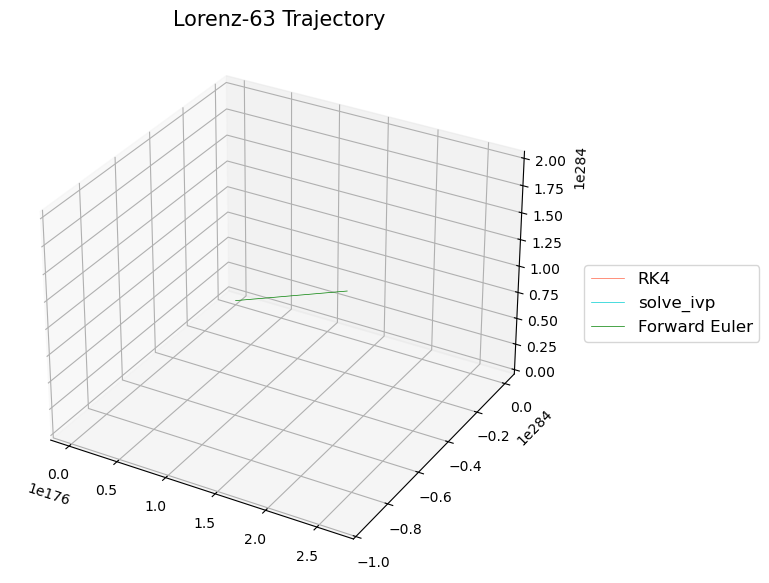

In [42]:
# Plot the trajectory in 3D phase space between the x, y, and z space. 
# The tomato line represents the forward euler solution, while the green  line represents the solution obtained using solve_ivp. Ther blue line represents the solution obtained using RK4.
ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
ax.set_title('Lorenz-63 Trajectory', fontsize=15)
ax.plot(Y[0, :], Y[1, :], Y[2, :],'b', color='tomato', lw=0.5, label = 'RK4')
ax.plot(y_ivp[0, :], y_ivp[1, :], y_ivp[2, :], 'r', color='darkturquoise', lw=0.5, label = 'solve_ivp')
ax.plot(Y_euler[0, :], Y_euler[1, :], Y_euler[2, :], color='green', lw=0.5, label = 'Forward Euler')

ax.legend(
    ['RK4', 'solve_ivp', 'Forward Euler'],
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    fontsize = 12
)

plt.show()

### The code below is used to plot and create an interactive html for the trajectory in 3D space. 

In [43]:
# import plotly.graph_objects as go
# #Plot state evolution in interactive x, y, z, space. 
# ax = plt.figure(figsize=(7,7)).add_subplot(projection='3d')
# ax.set_title('Lorenz-63 Trajectory', fontsize=15)
# ax.plot(Y_euler[0, :], Y_euler[1, :], Y_euler[2, :], color='blue', lw=0.5, label = 'Forward Euler')
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.grid(True)

# ax.legend(
#     ['Forward Euler'],
#     loc='center left',
#     bbox_to_anchor=(1.05, 0.5),
#     fontsize = 12
# )

# fig = plt.figure(figsize=(7,7))
# ax = fig.add_subplot(projection='3d')

# #Create a clear background for the final result. 
# ax.plot(
#     Y_euler[0, :],
#     Y_euler[1, :],
#     Y_euler[2, :],
#     color='blue',
#     lw=0.5,
#     label='Forward Euler'
# )

# # Remove grid
# ax.grid(False)

# # Remove the gray background panes
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False

# # Make pane edges invisible
# ax.xaxis.pane.set_edgecolor('none')
# ax.yaxis.pane.set_edgecolor('none')
# ax.zaxis.pane.set_edgecolor('none')

# # Remove axis lines, ticks, and labels
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_zticks([])

# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_zlabel("")

# # Hide the axis frame
# ax.set_axis_off()


# fig = go.Figure()

# fig.add_trace(
#     go.Scatter3d(
#         x=Y_euler[0, :],
#         y=Y_euler[1, :],
#         z=Y_euler[2, :],
#         mode='lines',
#         line=dict(color='blue', width=2),
#         name='Forward Euler'
#     )
# )

# fig.update_layout(
#     title='Lorenz-63 Trajectory',
#     scene=dict(
#         xaxis_visible=False,
#         yaxis_visible=False,
#         zaxis_visible=False,
#         bgcolor='white'
#     ),
#     showlegend=False
# )

# fig.write_html("Euler_interactive.html")

In [44]:
# !!! Turn plotting into a function


# def create_3d_plot(data, title):
#     df = pd.DataFrame(data)
#     fig = px.scatter_3d(df, x='X', y='Y', z='Z', title=title)
#     fig.update_traces(mode='lines', line=dict(width=2))
#     fig.update_layout(width=600, height=600)
#     return fig

#Euler Interactive 3D Plot
df = pd.DataFrame({
    'X': Y_euler[0, :],
    'Y': Y_euler[1, :],
    'Z': Y_euler[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - Lorenz63 Euler")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600,
#     scene=dict(
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         zaxis=dict(visible=False),
#         bgcolor="rgba(0,0,0,0)"
#     ),
#     paper_bgcolor="white",
)
fig.show()

df = pd.DataFrame({
    'X': y_ivp[0, :],
    'Y': y_ivp[1, :],
    'Z': y_ivp[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - solve_ivp")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600)
fig.show()

df=pd.DataFrame({
    'X': Y[0, :],
    'Y': Y[1, :],
    'Z': Y[2, :]
})

fig = px.scatter_3d(df, x='X', y='Y', z='Z', title="Interactive 3D Plot - Lorenz63 RK4")
fig.update_traces(mode='lines', line=dict(width=2))
fig.update_layout(width=600, height=600)
fig.show()


## Neural Networks 
This part of the code will focus on the creation and training of neural networks using pytorch 

## Extra Code Chunks

In [45]:
# # This code allows for an interactive Euler plot, but it 
# import numpy as np
# import matplotlib.pyplot as plt

# # Create figure
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# # Labels
# ax.set_title("Forward Euler Lorenz-63 Animation")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# # Set axis limits
# ax.set_xlim(np.min(Y_euler[0]), np.max(Y_euler[0]))
# ax.set_ylim(np.min(Y_euler[1]), np.max(Y_euler[1]))
# ax.set_zlim(np.min(Y_euler[2]), np.max(Y_euler[2]))

# # Empty line and moving point
# line, = ax.plot([], [], [], color='green', lw=1, label='Forward Euler')
# point, = ax.plot([], [], [], 'ro', markersize=6)

# ax.legend()

# # Animation function
# def update(frame):
#     # Update trajectory
#     line.set_data(Y_euler[0, :frame], Y_euler[1, :frame])
#     line.set_3d_properties(Y_euler[2, :frame])

#     # Update moving point
#     point.set_data([Y_euler[0, frame]], [Y_euler[1, frame]])
#     point.set_3d_properties([Y_euler[2, frame]])

#     return line, point

# # Create animation
# animation = FuncAnimation(
#     fig,
#     update,
#     frames=Y_euler.shape[1],
#     interval=20,
#     blit=False
# )

# plt.show()

In [46]:
# #This code creates a static graph of the lorenz method with the Euler method. 
# import numpy as np 
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# #Forward Euler integration
# ax = plt.figure(figsize=(10, 7)).add_subplot(projection='3d')
# ax.set_title('Lorenz-63 Trajectory', fontsize=15)
# ax.plot(Y_euler[0, :], Y_euler[1, :], Y_euler[2, :], color='green', lw=0.5, label = 'Forward Euler')


# animation = FuncAnimation(
#     fig = fig, 
#     func = euler_step,
#     frames = len(t_euler),
#     interval = 50,
#     blit = False 
# )


# plt.show()

In [47]:
# import plotly.graph_objects as go
# #Create a clear background for the final result. 
# ax.plot(
#     Y_euler[0, :],
#     Y_euler[1, :],
#     Y_euler[2, :],
#     color='blue',
#     lw=0.5,
#     label='Forward Euler'
# )

# # Remove grid
# ax.grid(False)

# # Remove the gray background panes
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False

# # Make pane edges invisible
# ax.xaxis.pane.set_edgecolor('none')
# ax.yaxis.pane.set_edgecolor('none')
# ax.zaxis.pane.set_edgecolor('none')

# # Remove axis lines, ticks, and labels
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_zticks([])

# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_zlabel("")

# # Hide the axis frame
# ax.set_axis_off()


# fig = go.Figure()

# fig.add_trace(
#     go.Scatter3d(
#         x=Y[0, :],
#         y=Y[1, :],
#         z=Y[2, :],
#         mode='lines',
#         line=dict(color='blue', width=2),
#         name='Forward Euler'
#     )
# )

# fig.update_layout(
#     title='RK4 Trajectory',
#     scene=dict(
#         xaxis_visible=False,
#         yaxis_visible=False,
#         zaxis_visible=False,
#         bgcolor='white'
#     ),
#     showlegend=False
# )

# fig.write_html("RK4_interactive.html")

# # Create figure
# fig = plt.figure(figsize=(7,7))
# ax = fig.add_subplot(111, projection='3d')

# # Set title and labels
# ax.set_title("Lorenz-63 Trajectory - RK4")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# # # Set fixed axis limits
# # ax.set_xlim(np.min(Y_euler[0]), np.max(Y_euler[0]))
# # ax.set_ylim(np.min(Y_euler[1]), np.max(Y_euler[1]))
# # ax.set_zlim(np.min(Y_euler[2]), np.max(Y_euler[2]))

# # Create empty trajectory and point
# trajectory, = ax.plot([], [], [], color='blue', lw=1, label='Trajectory')
# point, = ax.plot([], [], [], 'ro', markersize=4, color = 'blue', label='Current State')

# ax.grid(False)